In [4]:
from imageio.v3 import imread, imwrite
from lumicks import pylake

import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [7]:
channel = 0
force_ranges = [0,10,20,30,40,50,60]
path = '/Users/sc13967/Library/CloudStorage/OneDrive-UniversityofBristol/People/Gemma Fisher/2026-06-11 Quantification of cohesin retention versus applied lateral force'

Processing: 20240819-150426 Kymograph 5.h5
Processing: 20240819-152630 Kymograph 8.h5
Processing: 20240819-153056 Kymograph 10.h5
Processing: 20240819-153541 Kymograph 11.h5
Processing: 20240819-152841 Kymograph 9.h5


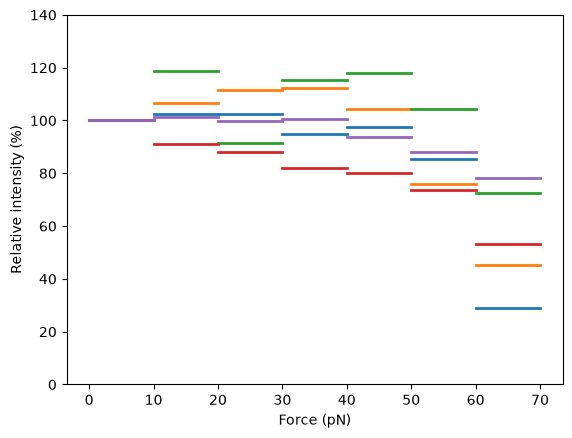

In [6]:
fig = plt.figure()

file_count = 0
for filename in os.listdir(path):
    if os.path.splitext(filename)[1] != ".h5":
        file_count += 1

file_idx = 0
for filename in os.listdir(path):
    if os.path.splitext(filename)[1] != ".h5":
        continue
    
    print(f"Processing: {filename}")
    
    # Reading .h5 file ahd kymograph    
    pylake_file = pylake.File(f"{path}/{filename}")
    kymo = next(iter(pylake_file.kymos.values()))
    
    # Getting forces
    line_timestamp_ranges = kymo.line_timestamp_ranges()
    forces = pylake_file.force2x.downsampled_over(line_timestamp_ranges).data
        
    # Getting kymograph image
    kymo_image = kymo.get_image()[:,:,channel]
    
    # Loading kymograph mask
    mask_image = imread(f"{path}/{filename[:-3]}_kymograph0_mask.tif")
    active_timepoints = [np.sum(mask_image, axis=0) > 0]
    
    # For each specified force range, getting the pixels within the mask
    # Also, storing a labelled mask showing the pixels used
    intensities = {}
    label_mask = np.zeros(mask_image.shape)
    first_force = 0
    for i in range(len(force_ranges)-1):
        mid_force = force_ranges[i] + (force_ranges[i+1]-force_ranges[i])/2
        
        curr_mask = mask_image.copy()
        curr_mask[:,forces<force_ranges[i]] = 0
        curr_mask[:,forces>=force_ranges[i+1]] = 0
        curr_mask[:,not active_timepoints] = 0
        label_mask[curr_mask>0] = i+1
        
        mean_intensity = np.mean(kymo_image[curr_mask>0])
        
        if i == 0:
            first_force = mean_intensity
            
        intensities[mid_force] = [mean_intensity,100*mean_intensity/first_force, force_ranges[i], force_ranges[i+1]]
    
    colour = plt.cm.tab10(file_idx)
    for force, intensity in intensities.items():
        plt.plot([intensity[2],intensity[3]], [intensity[1],intensity[1]],color=colour, linewidth=2)
    
    imwrite(f"{path}/{filename[:-3]}_kymograph0_label_mask.tif", label_mask)
    
    with open(f"{path}/{filename[:-3]}_kymograph0_intensities.csv", 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Force","Intensity","Relative intensity (%)","Min force (pN)", "Max force (pN)"])
        for force, intensity in intensities.items():
            writer.writerow([force,intensity[0],intensity[1],intensity[2],intensity[3]])
            
    file_idx += 1

plt.ylim(0,140)
plt.xlabel("Force (pN)")
plt.ylabel("Relative intensity (%)")    
plt.savefig(f"{path}/Intensity_vs_force.png")
plt.savefig(f"{path}/Intensity_vs_force.svg")
    